# Introduction to Deep Learning with PyTorch (Part 1)

**Vanessa Gómez Verdejo,  Pablo Martínez Olmos, Alejandro Lancho Serrano, Emilio Parrado Hernández**

Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~emipar/BBVA/INTRO/img/logo_uc3m_foot.jpg' width=400 />


In [54]:
import torch
import numpy as np
import matplotlib.pyplot as plt


Some examples and figures in this notebook are adapted from
https://lightning.ai/courses/deep-learning-fundamentals/

# 1. PyTorch

What is it PyTorch? Pythorch is a free and open source software library characteized by being:
1. A tensor library
2. An automatic differentiation engine
3. Deep learning library

## 1. Torch Tensors

A tensor is data container for storing multidimensional arrays

<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_1.png" width=60%>

torch.tensor $\approx$ numpy.array
$+$ GPU support
$+$ automatic differentation

In [55]:
# Create tensor from list
data = [[1, 2], [3, 4]]
x = torch.tensor(data)


In [56]:
# Create tensor from numpy array
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

PyTorch provides several ways to initialize tensors:

In [57]:
x_empty = torch.empty(3, 3)       # Uninitialized 3x3 tensor
x_zeros = torch.zeros(3, 3)       # 3x3 tensor filled with zeros
x_random = torch.rand(3, 3)       # Random values in [0, 1)
x_identity = torch.eye(3)         # 3x3 identity matrix

In [58]:
# Create tensor from another tensor
x_ones = torch.ones_like(x) # keep data type
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x, dtype=torch.float) # overrides data type
print(f"Random Tensor: \n {x_rand} \n")


Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.6843, 0.7124],
        [0.1024, 0.9347]]) 



Each tensor has attributes that describe its properties:

In [59]:
print(f"Data Type: {x.dtype}")
print(f"Device: {x.device}")
print(f"Shape: {x.shape}")
print(f"Number of dims: {x.ndim}")
print(f"Requires Gradient: {x.requires_grad}")

Data Type: torch.int64
Device: cpu
Shape: torch.Size([2, 2])
Number of dims: 2
Requires Gradient: False


In [60]:
x = x.to(dtype=torch.float32)
print(f"Data Type: {x.dtype}")

Data Type: torch.float32


Tip: It is preferable to use PyTorch tensors with datatype of float32 instead of float64. This is because single precision is fine for most ML tasks, while you save in memory and improve in speed. Looking at GPU compute, at best (V100) double precision is 2x slower than single precision. On a 2080Ti it's 24x slower!

Move tensors to GPU:

To move a tensor to an accelerator, use the method to() with the name of the accelerator to use (e.g. cuda for GPU). If the accelerator is not recognized by PyTorch, the method raises a runtime error. You can check if a GPU is available with the method torch.cuda.is_available() .

In [61]:
# Move a tensor to the GPU if available
x = torch.rand(3,4)
if torch.cuda.is_available():
  x = x.to("cuda")
print(f"Device: {x.device}")

Device: cuda:0


Convert Tensors to Numpy Arrays

In [62]:
# NumPy to Tensor
np_array = np.zeros((3, 3))
x = torch.from_numpy(np_array)# Tensor to NumPy
print(x)
np_array_back = x.numpy()
print(np_array_back)

tensor([[0., 0., 0.],
        [0., 0., 0.],
        [0., 0., 0.]], dtype=torch.float64)
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


In [63]:
# If you have a one-element tensor, you can access its value
# with .item()
agg_x = x.sum()
agg_item = agg_x.item()
print(agg_item)

0.0


Tensor.detach() is used to detach ("separar") a tensor from the current computational graph. It returns a new tensor that doesn't require a gradient.

In [64]:
# create a tensor with requires_gradient=true
x = torch.tensor(2.0, requires_grad = True)

# print the tensor
print("Tensor:", x)

# tensor.detach operation
x_detach = x.detach()
print("Tensor with detach:", x_detach)

Tensor: tensor(2., requires_grad=True)
Tensor with detach: tensor(2.)


In [65]:
# define a tensor with requires_grad=true
x = torch.rand(3, requires_grad = True)
print("x:", x)

# apply above tensor to use detach()
y = 3 + x
z = 3 * x.detach()

print("y:", y)
print("z:", z)

x: tensor([0.4495, 0.2544, 0.5104], requires_grad=True)
y: tensor([3.4495, 3.2544, 3.5104], grad_fn=<AddBackward0>)
z: tensor([1.3485, 0.7633, 1.5311])


## 2. Tensor Indexing

In [66]:
x = torch.rand(3, 2)
print(x)

# Access specific elements
print(x[0, 0])  # First element
print(x[:, 1])  # Second column
print(x[1, :])  # Second row

tensor([[0.6436, 0.6804],
        [0.0972, 0.7416],
        [0.5514, 0.8449]])
tensor(0.6436)
tensor([0.6804, 0.7416, 0.8449])
tensor([0.0972, 0.7416])


## 3. Tensor Reshaping

Use .view() or .reshape() to reshape tensors:

In [67]:
x = torch.arange(6)
print(x)
# Reshape into 3x2 matrix
x_reshaped = x.view(3, 2)
print(x_reshaped)

tensor([0, 1, 2, 3, 4, 5])
tensor([[0, 1],
        [2, 3],
        [4, 5]])


In [68]:
x_reshaped = x.view(-1, 2)  # With -1 we don't need to specify the correct dimension
print(x_reshaped)
x_reshaped = x.view(-1, 3)  # With -1 we don't need to specify the correct dimension
print(x_reshaped)

tensor([[0, 1],
        [2, 3],
        [4, 5]])
tensor([[0, 1, 2],
        [3, 4, 5]])


## 4. Tensor Mathematical Operations

PyTorch implements the most common operations over tensors like matrix multiplications, concatenations, indexing, and aggregations. The syntax is similar to NumPy syntax.

In [69]:
x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

Basic element-wise operations

In [70]:
# Element-wise addition
z_add = x + y
print(z_add)
z_add = x.add(y)
print(z_add)

# Element-wise subtraction
z_sub = x - y
print(z_sub)
z_sub = x.sub(y)
print(z_sub)

# Element-wise multiplication
z_mul = x * y
print(z_mul)
z_mul = x.mul(y)
print(z_mul)

# Element-wise division
z_div = x / y
print(z_div)
z_div = x.div(y)
print(z_div)

tensor([5, 7, 9])
tensor([5, 7, 9])
tensor([-3, -3, -3])
tensor([-3, -3, -3])
tensor([ 4, 10, 18])
tensor([ 4, 10, 18])
tensor([0.2500, 0.4000, 0.5000])
tensor([0.2500, 0.4000, 0.5000])


We can do dot multiplication with two of the 1D tensors with dot()

In [71]:
x = torch.tensor([2, -5, 4])
y = torch.tensor([3, 6, -1])

# Dot product with 1-D tensors
z_dot = torch.dot(x, y)
print(z_dot)
z_dot = x.dot(y)
print(z_dot)

tensor(-28)
tensor(-28)


For matrix operations (2-D tensors), use torch.matmul, torch.mm or the @ operator:

In [72]:
x1 = torch.rand(2, 3)
x2 = torch.rand(3, 2)
print(x1)
print(x2)

tensor([[0.8534, 0.1062, 0.9802],
        [0.0083, 0.7874, 0.5352]])
tensor([[0.7366, 0.2296],
        [0.8006, 0.2526],
        [0.0581, 0.6675]])


In [73]:
# Matrix multiplication
result = torch.mm(x1, x2)
print(result)

result = torch.matmul(x1, x2)
print(result)
result = x1.matmul(x2)
print(result)

# From Python 3.5 we can use @ instead of matmul
result = x1 @ x2
print(result)

tensor([[0.7705, 0.8771],
        [0.6676, 0.5580]])
tensor([[0.7705, 0.8771],
        [0.6676, 0.5580]])
tensor([[0.7705, 0.8771],
        [0.6676, 0.5580]])
tensor([[0.7705, 0.8771],
        [0.6676, 0.5580]])


In [74]:
# Matrix multiplication and matrix transpose
y1 = x1 @ x1.T
y2 = x1.matmul(x1.T)
print(y1)
print(y2)

tensor([[1.7002, 0.6153],
        [0.6153, 0.9065]])
tensor([[1.7002, 0.6153],
        [0.6153, 0.9065]])


## 5. Broadcasting

A broadcasting process operates two tensors with different shapes. Normally, one of the operands has a particular dimension to be 1, which will be broadcast along the corresponding dimension of the other operator to perform the given calculation.

In [75]:
x1 = torch.rand(5, 5)
x2 = torch.ones(1, 5)
# Broadcasting x2 to match x1
result = x1 - x2
print(x1)
print(x2)
print(result)

tensor([[0.7737, 0.9956, 0.4477, 0.9810, 0.8212],
        [0.2520, 0.1143, 0.7804, 0.2261, 0.7293],
        [0.0718, 0.8648, 0.6499, 0.4425, 0.7293],
        [0.1440, 0.3907, 0.5049, 0.2111, 0.3722],
        [0.2844, 0.9765, 0.9248, 0.9312, 0.9087]])
tensor([[1., 1., 1., 1., 1.]])
tensor([[-0.2263, -0.0044, -0.5523, -0.0190, -0.1788],
        [-0.7480, -0.8857, -0.2196, -0.7739, -0.2707],
        [-0.9282, -0.1352, -0.3501, -0.5575, -0.2707],
        [-0.8560, -0.6093, -0.4951, -0.7889, -0.6278],
        [-0.7156, -0.0235, -0.0752, -0.0688, -0.0913]])


Two tensors are “broadcastable” if the following rules hold:
-  Each tensor has at least one dimension.
-  When iterating over the dimension sizes, starting at the trailing dimension (the right most dim), the dimension sizes must either be equal, one of them is 1, or one of them does not exist.

Lets look at some examples to understand these rules

In [76]:
x=torch.empty(5,7,3)
y=torch.empty(5,7,3)
# same shapes are always broadcastable (i.e. the above rules always hold)
result = x - y
print(x)
print(y)
print(result)

tensor([[[ 0.0000e+00,  0.0000e+00,  1.3383e-03],
         [ 0.0000e+00,  7.3596e-13,  0.0000e+00],
         [ 1.2323e+30,  4.3505e-41,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  1.4013e-45]],

        [[ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+00],
         [ 1.8217e-44,  0.0000e+00,  1.4013e-45],
         [ 0.0000e+00, -1.7014e+38,  1.1515e-40],
         [ 9.1837e-41,  4.1478e-43,  4.9466e-43],
         [ 0.0000e+00,  2.8240e-11,  0.0000e+00]],

        [[ 3.3510e-03,  0.0000e+00,  3.3529e-03],
         [ 0.0000e+00,  3.3511e-03,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  1.3383e-03],
         [ 0.0000e+00,  7.3596e-13,  0.0000e+00],
         [ 1.2317e+30,  4.3505e-41,  0.0000e+00],
         [ 0.0000e+00,  0.0000e+00,  0.0000e+0

In [77]:
x=torch.empty((0,))
y=torch.empty(2,2)
# x and y are not broadcastable, because x does not have at least 1 dimension

In [78]:
x=torch.empty(5,3,4,1)
y=torch.empty(  3,1,1)
# x and y are broadcastable.
# 1st trailing dimension: both have size 1
# 2nd trailing dimension: y has size 1
# 3rd trailing dimension: x size == y size
# 4th trailing dimension: y dimension doesn't exist
result = x - y
print(x)
print(y)
print(result)


tensor([[[[-1.4417e-11],
          [ 4.3506e-41],
          [ 3.3520e-03],
          [ 0.0000e+00]],

         [[ 1.8594e-11],
          [ 0.0000e+00],
          [ 7.7161e-11],
          [ 0.0000e+00]],

         [[ 0.0000e+00],
          [ 0.0000e+00],
          [ 1.3291e-03],
          [ 0.0000e+00]]],


        [[[ 7.3596e-13],
          [ 0.0000e+00],
          [ 1.2316e+30],
          [ 4.3505e-41]],

         [[ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]],

         [[ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]]],


        [[[ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]],

         [[ 1.4013e-45],
          [ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]],

         [[ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00],
          [ 0.0000e+00]]],


        [[[ 0.0000e+00],
          [ 0.0000e+00],
          [ 4.6243e-44],
 

In [79]:
x=torch.empty(5,2,4,1)
y=torch.empty(  3,1,1)
# x and y are not broadcastable, because in the 3rd trailing dimension 2 != 3

**Batch matrix multiplication (BMM)**

BMM involves matrix multiplication with tensors with more than two dimensions.

If both arguments are at least 1-dimensional and at least one argument is N-dimensional (where N > 2), then a batched matrix multiply is returned.

- Case 1: If the second argument is 1-dimensional, a 1 is appended to its dimension for the purpose of the batched matrix multiple and removed after

In [80]:
# batched matrix times broadcasted vector
x1 = torch.randn(10, 3, 4)
x2 = torch.randn(4)
op = torch.matmul(x1, x2)

# second argument is x2 and its 1 dimensional
# so it will be appended with 1 that makes its shape [4,1]
# then we multiply each of [3,4] matrix from x1 with
# x2, [3,4] X [4,1] -> [3,1] => [3], as appended 1 dim is removed
# so there are 10 [3,4] matrices that will gives 10 of [3] vectors => [10,3]
op.shape

torch.Size([10, 3])

* Case 2: If the first argument is 1-dimensional, a 1 is prepended to its dimension for the purpose of the batched matrix multiply and removed after.

In [81]:
# broadcasted vector x batched matrix
tensor1 = torch.randn(4)
tensor2 = torch.randn(10, 4, 3)
op = torch.matmul(tensor1, tensor2)

# first argument is x1 and its 1 dimensional
# so it will be prepended with 1 that makes its shape [1,4]
# then we multiply each of [4,3] matrix from x2 with
# x1, [1,4]x[4,3] -> [1,3] => [3], as prepended 1 dim is removed
# so there are 10 [4,3] matrices that will gives 10 of [3] vectors => [10,3]
op.shape

torch.Size([10, 3])

The non-matrix (i.e. batch) dimensions are broadcasted (and thus must be broadcastable). For example, if input is a (j×1×n×n) tensor and other is a (k×n×n) tensor, out will be a (j×k×n×n) tensor.

In [82]:
# batched matrix x batched matrix
x1 = torch.randn(10, 3, 4)
x2 = torch.randn(10, 4, 5)
torch.matmul(x1, x2).size()

# because [3,4] x [4,5] -> [3,5] and there are 10 of them so its [10, 3,5]


torch.Size([10, 3, 5])

In [83]:
# batched matrix x broadcasted matrix
x1 = torch.randn(10, 3, 4)
x2 = torch.randn(4, 5)
torch.matmul(x1, x2).size()

torch.Size([10, 3, 5])

In summary,
* torch.mul - performs a elementwise multiplication with broadcasting - (Tensor) by (Tensor or Number)
* torch.mm - performs a matrix multiplication without broadcasting - (2D tensor) by (2D tensor)
* torch.matmul - matrix product with broadcasting - (Tensor) by (Tensor) with different behaviors depending on the tensor shapes (dot product, matrix product, batched matrix products).


# 2. The Logistic Regressor Classifier

<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_2.png" width=60%>

where $\sigma(z)$ is the sigmoid function:

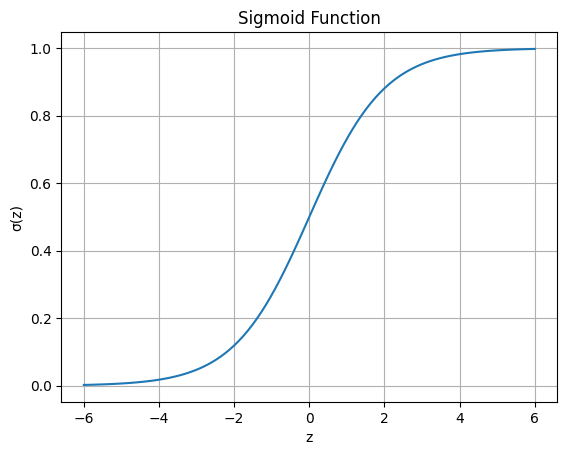

In [84]:
def sigmoid(z):
  return 1 / (1 + np.exp(-z))

# Generate x values
z = np.linspace(-6, 6, 100)

# Calculate corresponding y values using the sigmoid function
y = sigmoid(z)

# Create the plot
plt.plot(z, y)

# Add labels and title
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.title("Sigmoid Function")

# Add grid for better readability
plt.grid(True)

# Display the plot
plt.show()


This way, for the binary case,  the ouput of the **logistic regression (LR)** estimates the posterior probability of tha class $1$ given the input data $\bf x$:

$$\hat{P}(y=1| {\bf x}) = \sigma(z) = \frac{1}{1+\exp(-{\bf w}^T {\bf x}-b)}$$

where the weight vector $\bf w$ and the bias $b$ will be the classifier parameters to be learnt.



## Loss function


To learn these parameters, LR maximizes the likelihood of  $\bf w$ and $b$ computed over all training data, i.e.,

$${\bf w^*}, b^* =  \displaystyle \underset{{\bf w}, b}{\operatorname{max}} \prod_{i=1}^N p(y^{(i)}|\mathbf{x}^{(i)},{\bf w}, b) = \displaystyle \underset{{\bf w}, b}{\operatorname{max}}  L({\bf w}, b)$$

Taking into account that the likelihood of $({\bf w}, b)$ over the data set$ \{{\bf x}^{(i)}, y^{(i)}\}_{i=1}^N$ is $\hat{P}(y=1| {\bf x}) = \sigma(z^{(i)})$ if its label is 1, while $1- \sigma(z^{(i)}) $ is the probability of belonging to class $0$, the  likelihood over all training data is:

$$L({\bf w}, b) = \prod_{i=1}^N \sigma(z^{(i)})^{y^{(i)}}\left(1- \sigma(z^{(i)})\right)^{1-y^{(i)}} $$

and, then, the log-likelihood for N observations is:

$$l({\bf w}, b) =\log{L({\bf w}, b)} = \sum_{i=1}^N \left\lbrace  y^{(i)}\log \sigma(z^{(i)})  + (1-y^{(i)}) \log\left(  1- \sigma(z^{(i)}) \right)  \right\rbrace  $$

So the computation of the weight vector $\bf w$ and the bias $b$ is usually done by minimizing the **Negative Log Likelihood (NLL)**:
$$ {\bf w^*}, b^* =  \displaystyle \underset{{\bf w}, b}{\operatorname{min}}
\sum_{i=1}^N - \left\lbrace  y^{(i)}\log \sigma(z^{(i)})  + (1-y^{(i)}) \log\left(  1- \sigma(z^{(i)}) \right)  \right\rbrace $$

This loss function is also known as **Binary Cross-Entropy (BCE)**.

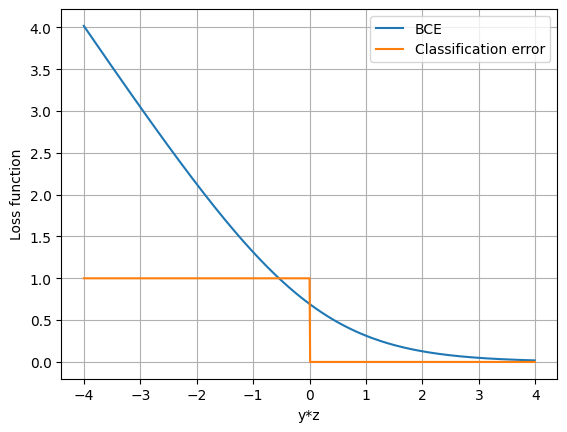

In [85]:
# Plot the logistic regression loss function (un upper bound of the classfication error)
z = np.arange(-4,4,0.01)
y = 1
l_w = np.log(1+ np.exp(z))-y*z
plt.figure()
plt.plot(y*z,l_w, label='BCE')


# Classification error
e_class = np.zeros(z.shape)
e_class[y*z<0] =1
plt.plot(y*z,e_class, label='Classification error')

plt.legend()
plt.xlabel('y*z')
plt.ylabel('Loss function')

# Add grid for better readability
plt.grid(True)

# Display the plot
plt.show()

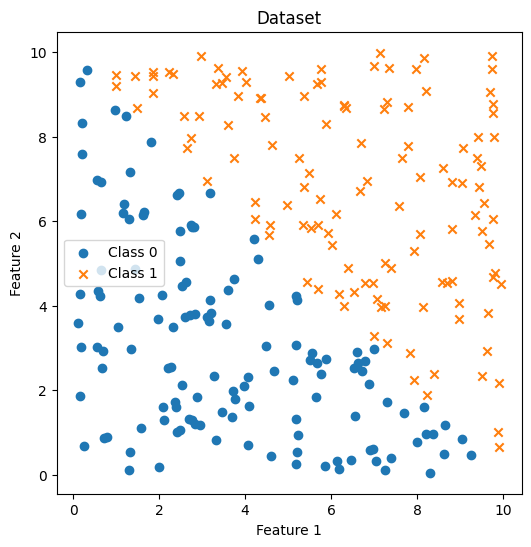

In [86]:
# Generate a synthetic dataset
np.random.seed(0)
X = np.random.rand(256, 2) * 10  # 100 samples, 2 features
y = (X[:, 0] + X[:, 1] > 10).astype(int)  # Binary classification


# Plot the dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", marker='o')
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", marker='x')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset")
plt.legend()
plt.show()


There are different ways to compute this loss...

In [87]:
import torch.nn.functional as F
# Define random weights and bias
w = np.random.rand(2)
b = np.random.rand(1)

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Calculate the linear combination of features and weights (z) -> logits
z = np.dot(X, w) + b

# Calculate the predicted probabilities using the sigmoid function
y_pred = sigmoid(z)

def binary_cross_entropy(y_true, y_pred):
  """Calculates the standard binary cross-entropy loss."""
  return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

# Calculate the standard BCE loss
standard_bce = binary_cross_entropy(y, y_pred)
print(f"Standard BCE: {standard_bce}")

# Convert to tensors
y_true_tensor = torch.tensor(y, dtype=torch.float32)
y_pred_tensor = torch.tensor(y_pred, dtype=torch.float32)
z_tensor = torch.tensor(z, dtype=torch.float32)

# Calculate the standard binary cross-entropy loss using PyTorch
standard_bce_pytorch = F.binary_cross_entropy(y_pred_tensor, y_true_tensor)

# Calculate the BCE loss with logits using PyTorch: best practice
bce_with_logits_pytorch = F.binary_cross_entropy_with_logits(z_tensor, y_true_tensor)

print(f"Standard BCE (PyTorch): {standard_bce_pytorch.item()}")
print(f"BCE with logits (PyTorch): {bce_with_logits_pytorch.item()}")


Standard BCE: 2.787280876074856
Standard BCE (PyTorch): 2.787281036376953
BCE with logits (PyTorch): 2.787281036376953


How can I minimize this loss? $⇒$ Gradient Descent Algorithm

## Stochastic Gradient Descent (SGD) algorithm

The **gradient descent** is an iterative optimization algorithm used to minimize a loss function, which represents how far the model’s predictions are from the actual values. The main goal is to adjust the parameters of a model (weights, biases, etc.) so that the loss is minimized.

The update rule for the traditional gradient descent algorithm is:

$$ {\bf w}_{t+1} = {\bf w}_{t} - \eta ∇_{\bf w} J({\bf w}, b)$$
$$ {b}_{t+1} = {b}_{t} - \eta  \frac{d J({\bf w}, b)}{d b}$$

where $\eta $ is the learning rate. In the LR case $ J({\bf w}, b) = -l({\bf w}, b)$.


<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_3.png" width=50%>

In traditional gradient descent, the gradients are computed based on the entire dataset, which can be computationally expensive for large datasets.

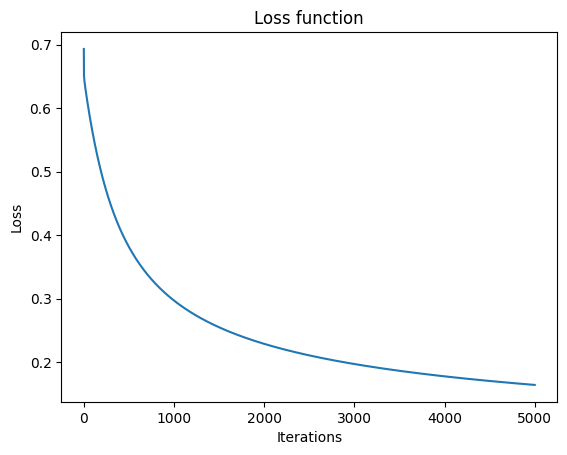

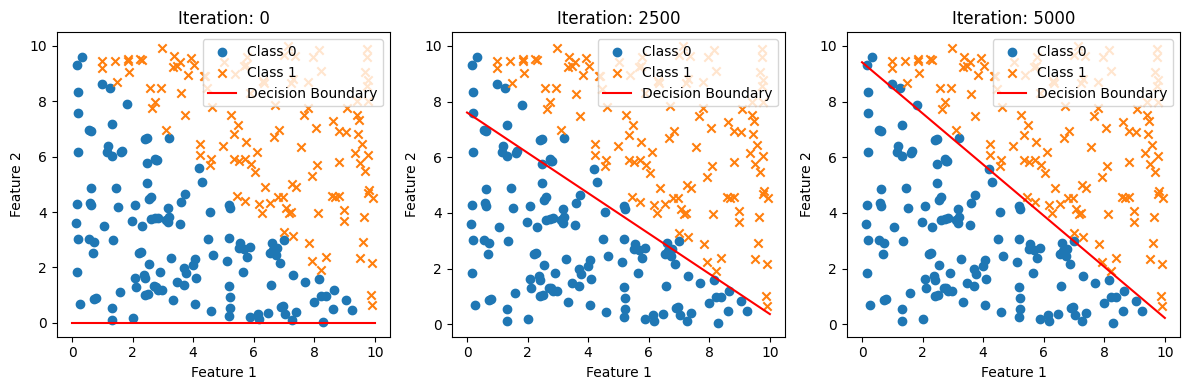

In [88]:
def gradient_descent(X, y, learning_rate=0.01, num_epochs=1000):
    m, n = X.shape
    X = np.insert(X, 0, 1, axis=1) # Add bias term
    w = np.zeros(n + 1)  # Initialize weights (including bias)

    loss_history = []
    weights_history = [w.copy()]  # Store weights for plotting

    for _ in range(num_epochs):
        z = np.dot(X, w)
        h = sigmoid(z)
        gradient = np.dot(X.T, (h - y)) / m
        w = w - learning_rate * gradient
        loss = -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))
        loss_history.append(loss)
        weights_history.append(w.copy())

    return w, loss_history, weights_history

# Train the model
num_epochs = 5000
w, loss_history, weights_history = gradient_descent(X, y, learning_rate=0.05, num_epochs=num_epochs)

#Plot the loss function
plt.plot(loss_history)
plt.title('Loss function')
plt.xlabel('Iterations')
plt.ylabel('Loss')

#Plot the decision boundary for different iterations
plt.figure(figsize=(12, 4))
for i, w_i in enumerate([weights_history[0], weights_history[500], weights_history[-1]]): # Initial, intermediate, and final weights

  plt.subplot(1, 3, i + 1)
  plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", marker='o')
  plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", marker='x')

  # Decision boundary
  x_boundary = np.linspace(0, 10, 100)
  y_boundary = -(w_i[1] * x_boundary + w_i[0]) / (w_i[2]+1e-12)
  plt.plot(x_boundary, y_boundary, color='red', label='Decision Boundary')


  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.title(f"Iteration: {int(0.5*i*num_epochs) if i else 0}")
  plt.legend()

plt.tight_layout()
plt.show()

**Stochastic Gradient Descent (SGD)** computes the gradient for each training example rather than the entire dataset:

$$ {\bf w}_{t+1} = {\bf w}_{t} - \eta ∇_{\bf w} J({\bf w}, b; {\bf x}^{(i)}, y^{(i)} )$$
$$ {b}_{t+1} = {b}_{t} - \eta  \frac{d J({\bf w}, b, {\bf x}^{(i)}, y^{(i)})}{d b}$$

where now $J({\bf w}, b, {\bf x}^{(i)}, y^{(i)})$ is the loss function compute over a unique sample; for the LR case, $J({\bf w}, b, {\bf x}^{(i)}, y^{(i)}) = - l({\bf w}, b, {\bf x}^{(i)}, y^{(i)}) =  y^{(i)}\log \sigma(z^{(i)})  + (1-y^{(i)}) \log\left(  1- \sigma(z^{(i)}) \right) $


So, in SGD, the parameter updates are made based on a single data point, not the entire dataset.

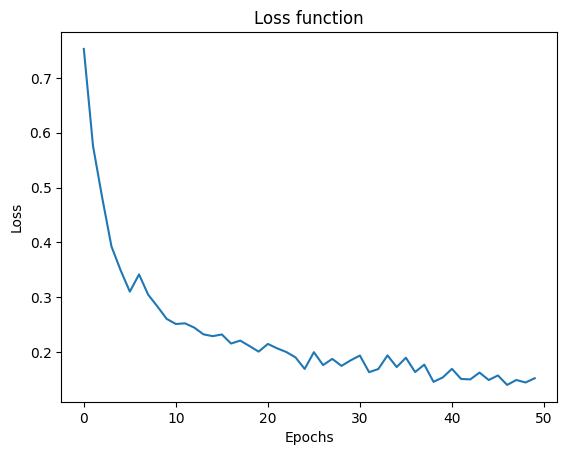

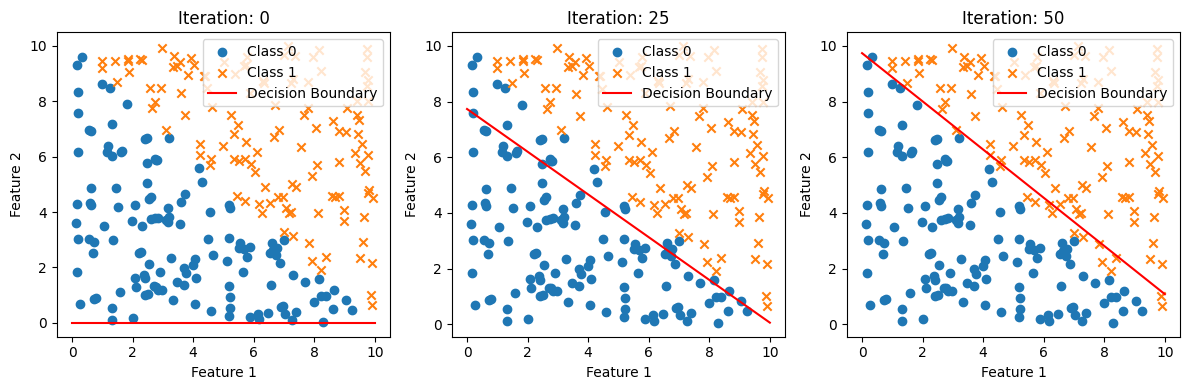

In [89]:
def stochastic_gradient_descent(X, y, learning_rate=0.01, epochs=100):
    m, n = X.shape
    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    w = np.zeros(n + 1)  # Initialize weights (including bias)

    loss_history = []
    weights_history = [w.copy()]

    for epoch in range(epochs):
        epoch_loss = 0
        # Shuffle the data for each epoch
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        y_shuffled = y[permutation]

        for i in range(m):
            xi = X_shuffled[i, :]
            yi = y_shuffled[i]
            z = np.dot(xi, w)
            h = sigmoid(z)
            gradient = xi * (h - yi)
            w = w - learning_rate * gradient
            loss = -(yi * np.log(h) + (1 - yi) * np.log(1 - h))
            epoch_loss += loss

        loss_history.append(epoch_loss/m) # Average loss for the epoch
        weights_history.append(w.copy())

    return w, loss_history, weights_history

# Train the model using SGD
num_epochs = 50
w, loss_history, weights_history = stochastic_gradient_descent(X, y, learning_rate=0.05, epochs=num_epochs)

# Plot the loss function
plt.plot(loss_history)
plt.title('Loss function')
plt.xlabel('Epochs')  # Changed to Epochs
plt.ylabel('Loss')
plt.show()

#Plot the decision boundary for different iterations
plt.figure(figsize=(12, 4))
for i, w_i in enumerate([weights_history[0], weights_history[25], weights_history[-1]]): # Initial, intermediate, and final weights

  plt.subplot(1, 3, i + 1)
  plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", marker='o')
  plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", marker='x')

  # Decision boundary
  x_boundary = np.linspace(0, 10, 100)
  y_boundary = -(w_i[1] * x_boundary + w_i[0]) / (w_i[2]+1e-12)
  plt.plot(x_boundary, y_boundary, color='red', label='Decision Boundary')


  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.title(f"Iteration: {int(0.5*i*num_epochs) if i else 0}")
  plt.legend()

plt.tight_layout()
plt.show()

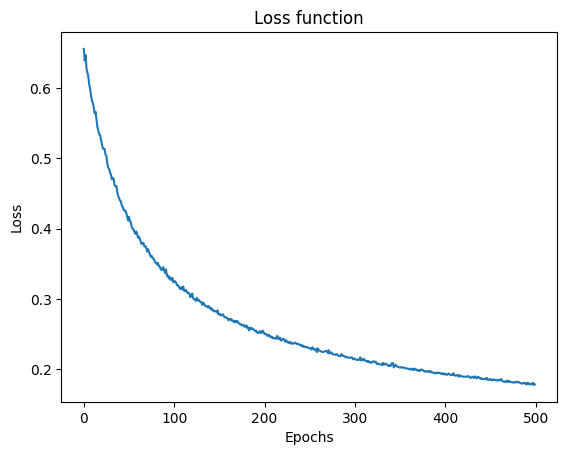

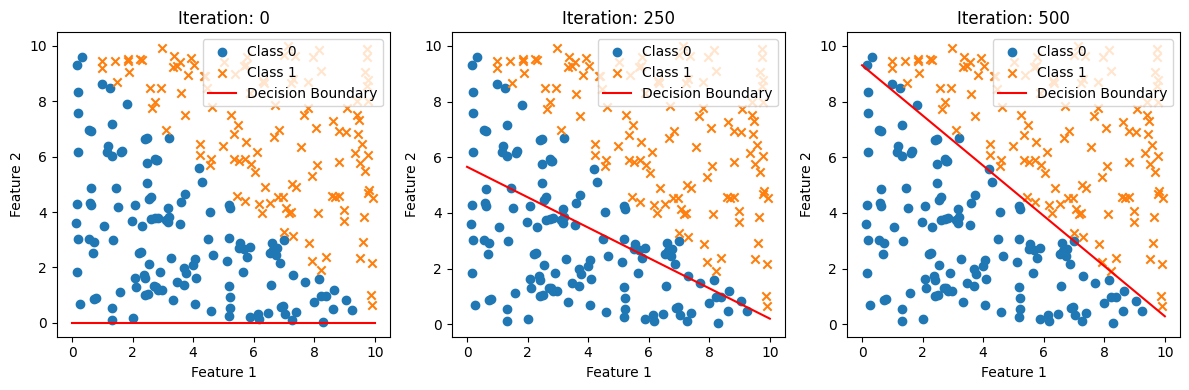

In [90]:

def stochastic_gradient_descent_minibatches(X, y, learning_rate=0.01, epochs=100, batch_size=32):
    m, n = X.shape
    X = np.insert(X, 0, 1, axis=1)  # Add bias term
    w = np.zeros(n + 1)  # Initialize weights (including bias)

    loss_history = []
    weights_history = [w.copy()]

    for epoch in range(epochs):
        epoch_loss = 0
        # Shuffle the data for each epoch
        permutation = np.random.permutation(m)
        X_shuffled = X[permutation]
        y_shuffled = y[permutation]

        for i in range(0, m, batch_size):
            xi = X_shuffled[i:i + batch_size]
            yi = y_shuffled[i:i + batch_size]
            z = np.dot(xi, w)
            h = sigmoid(z)
            gradient = np.dot(xi.T, (h - yi)) / batch_size  # Gradient for the minibatch
            w = w - learning_rate * gradient
            loss = -np.mean(yi * np.log(h) + (1 - yi) * np.log(1 - h))
            epoch_loss += loss

        loss_history.append(epoch_loss / (m // batch_size))  # Average loss for the epoch
        weights_history.append(w.copy())

    return w, loss_history, weights_history

# Train the model using SGD with minibatches
num_epochs = 500
w, loss_history, weights_history = stochastic_gradient_descent_minibatches(X, y, learning_rate=0.05, epochs=num_epochs, batch_size=32)

# Plot the loss function
plt.plot(loss_history)
plt.title('Loss function')
plt.xlabel('Epochs')  # Changed to Epochs
plt.ylabel('Loss')
plt.show()

#Plot the decision boundary for different iterations
plt.figure(figsize=(12, 4))
for i, w_i in enumerate([weights_history[0], weights_history[25], weights_history[-1]]): # Initial, intermediate, and final weights

  plt.subplot(1, 3, i + 1)
  plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", marker='o')
  plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", marker='x')

  # Decision boundary
  x_boundary = np.linspace(0, 10, 100)
  y_boundary = -(w_i[1] * x_boundary + w_i[0]) / (w_i[2]+1e-12)
  plt.plot(x_boundary, y_boundary, color='red', label='Decision Boundary')


  plt.xlabel("Feature 1")
  plt.ylabel("Feature 2")
  plt.title(f"Iteration: {int(0.5*i*num_epochs) if i else 0}")
  plt.legend()

plt.tight_layout()
plt.show()


<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_4.png" width=100%>


Remarks:
* Less noisy loss compared to stochastic descent with a single sample per update
* Faster than gradient descent, we use more than 1 update per epoch.

For efficient GPU use, the recomended minibatch sizes are: $2^4 = 16$,   $2^5 = 32$,   $2^6 = 64$,   $2^7 = 128$, ...

**Computing gradients with PyTorch**

The chain rule:

<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_5.png" width=60%>


In [91]:
# Compute the model output and loss
X = torch.tensor(X[:4,:], dtype=torch.float32)
y = torch.tensor(y[:4], dtype=torch.float32)

# Initizalize with zeros (or random)
w = torch.zeros(2, requires_grad=True)
b = torch.zeros(1, requires_grad=True)

z = X.matmul(w) + b
print(z)

loss = F.binary_cross_entropy_with_logits(z, y)
print(loss)

tensor([0., 0., 0., 0.], grad_fn=<AddBackward0>)
tensor(0.6931, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>)


In [92]:
# Now, we can compute the gradients with PyTorch
from torch.autograd import grad

# We can use Pytorch (using the chain rule) to compute the gradients
print('Compute gradients:')
grad_loss_w = grad(loss, w, retain_graph= True)
print(grad_loss_w)
grad_loss_b = grad(loss, b, retain_graph= True)
print(grad_loss_b)

# Or even easy with the .backward() function
print('Using backward:')
loss.backward()
print(w.grad)
print(b.grad)

Compute gradients:
(tensor([-2.5160, -3.4972]),)
(tensor([-0.5000]),)
Using backward:
tensor([-2.5160, -3.4972])
tensor([-0.5000])


As we see next, these gradients can be used by the optimizer (SGD) to update the model parameters...

## Implementing a Logistic Regression Classifier with PyTorch

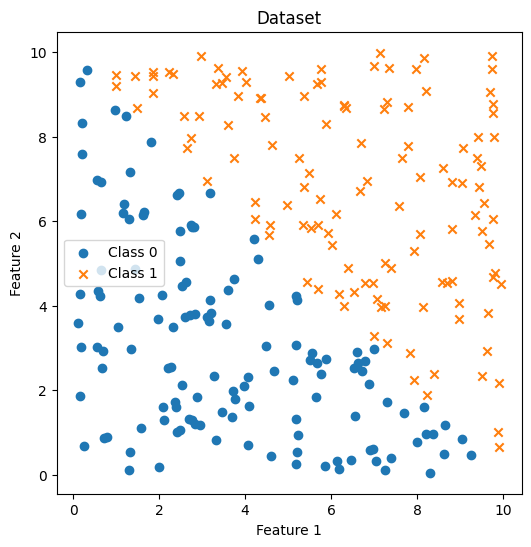

In [93]:
# Generate again our synthetic dataset
np.random.seed(0)
X = np.random.rand(256, 2) * 10  # 100 samples, 2 features
y = (X[:, 0] + X[:, 1] > 10).astype(int)  # Binary classification

# Plot the dataset
plt.figure(figsize=(6, 6))
plt.scatter(X[y == 0, 0], X[y == 0, 1], label="Class 0", marker='o')
plt.scatter(X[y == 1, 0], X[y == 1, 1], label="Class 1", marker='x')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Dataset")
plt.legend()
plt.show()


### 1.Define a class for our model:
* \_\_init\_\_()
* forward()

In [94]:
class LogisticRegression(torch.nn.Module):

    def __init__(self, num_features):
        super().__init__()
        self.linear = torch.nn.Linear(num_features, 1)  # PyTorch NN implementing  X.matmul(w) +b

    def forward(self, x):
        logits = self.linear(x)
        #probas = torch.sigmoid(logits)
        return logits

In [95]:
# Check the model
torch.manual_seed(1)
model = LogisticRegression(num_features=2)

# To make predictions, we do not need gradient computation
with torch.no_grad():
    logits = model(torch.tensor(X,dtype=torch.float32))

print(logits[:5])

tensor([[-0.3696],
        [ 0.3585],
        [-0.6094],
        [-1.3260],
        [ 2.1773]])


### 2.Define a Dataset class to load the data set (in mini-batches) with DataLoaders

* \_\_init\_\_(): set up attributes
* \_\_len\_\_(): returns the length of the dataset
* \_\_get\_item\_\_(): define how to load a single record (training/test example)

In [96]:
from torch.utils.data import Dataset, DataLoader

class MyDataset(Dataset):
    def __init__(self, X, y):
        self.features = torch.tensor(X, dtype=torch.float32)
        self.labels = torch.tensor(y, dtype=torch.float32)

    def __getitem__(self, index):
        x = self.features[index]
        y = self.labels[index]
        return x, y

    def __len__(self):
        return self.labels.shape[0]


This class can be use to generate DataLoaders to generate train, val and/or test partitions and to work easily with mini-batches.

In [97]:
# Here, we only have training data
train_ds = MyDataset(X, y)

train_loader = DataLoader(
    dataset=train_ds,
    batch_size=10,
    shuffle=True,
)

# We can create other Data loaders for validation o test subsets

In short, the class Dataset retrieves our dataset's features and labels one sample at a time (method \_\_get\_item\_\_()). While training a model, we typically want to pass samples in "minibatches", reshuffle the data at every epoch to reduce model overfitting, and use Python's multiprocessing to speed up data retrieval.

The class DataLoader is an iterable that abstracts this complexity for us!!!

### 3.The training loop

In [98]:
import torch.nn.functional as F

torch.manual_seed(1)

# Check for GPU availability and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# We use our LR class
model = LogisticRegression(num_features=2)

# Move the model to the device BEFORE the training loop
model.to(device)

# Include the SGD to optimize your model
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

num_epochs = 100

for epoch in range(num_epochs):
    # Set the model in training mode
    model = model.train()

    # Load the data with minibathes with the data loader
    for batch_idx, (data, labels) in enumerate(train_loader):
        # Move data and labels to the device
        data, labels = data.to(device), labels.to(device)

        # Computing the model output with .forward()
        logits = model(data)

        # As the model.forward returns the logits, we use the BCE loss with logits
        loss = F.binary_cross_entropy_with_logits(logits, labels.view(logits.shape))

        # Set the gradients to zero (remove gradients of previous iterations)
        optimizer.zero_grad()

        # Compute the gradients
        loss.backward()

        # Update model parameters
        optimizer.step()

    ### LOGGING
    if epoch%10 ==0:
      print(f'Epoch: {epoch+1:03d}/{num_epochs:03d}'
            f' | Loss: {loss:.2f}')


Using device: cuda
Epoch: 001/100 | Loss: 0.56
Epoch: 011/100 | Loss: 0.51
Epoch: 021/100 | Loss: 0.40
Epoch: 031/100 | Loss: 0.22
Epoch: 041/100 | Loss: 0.30
Epoch: 051/100 | Loss: 0.26
Epoch: 061/100 | Loss: 0.16
Epoch: 071/100 | Loss: 0.12
Epoch: 081/100 | Loss: 0.29
Epoch: 091/100 | Loss: 0.16


### 4.Evaluating the results

We can check the ouput of the last minibatch

In [99]:
probas = torch.sigmoid(logits)
probas

tensor([[0.4615],
        [0.9028],
        [0.0428],
        [0.9835],
        [0.9728],
        [0.0295]], device='cuda:0', grad_fn=<SigmoidBackward0>)

In [100]:
pred = torch.where(probas > 0.5, 1, 0)
pred

tensor([[0],
        [1],
        [0],
        [1],
        [1],
        [0]], device='cuda:0')

In [101]:
labels.view(pred.shape).to(pred.dtype)

tensor([[1],
        [1],
        [0],
        [1],
        [1],
        [0]], device='cuda:0')

We can design a function to evaluate the model accuracy

In [102]:
def compute_accuracy(model, dataloader):
    # Set the model in evaluation model
    # It disables layers like Dropout and BatchNorm, which behave differently during training and evaluation.
    model = model.eval()

    correct = 0.0
    total_examples = 0

    for idx, (data, labels) in enumerate(dataloader):
        # Move data and labels to the device
        data, labels = data.to(device), labels.to(device)

        with torch.no_grad(): # To save computations
            probas = torch.sigmoid(model(data))

        pred = torch.where(probas > 0.5, 1, 0)
        lab = labels.view(pred.shape).to(pred.dtype)

        compare = lab == pred
        correct += torch.sum(compare)
        total_examples += len(compare)

    return correct / total_examples

Let's generate test data for the evaluation

In [103]:
np.random.seed(10)
X2 = np.random.rand(256, 2) * 10  # 100 samples, 2 features
y2 = (X2[:, 0] + X2[:, 1] > 10).astype(int)  # Binary classification

test_ds = MyDataset(X2, y2)

test_loader = DataLoader(
    dataset=test_ds
)

In [104]:
test_acc = compute_accuracy(model, test_loader)
print(f"Accuracy: {test_acc*100}%")

Accuracy: 94.53125%


**Visualizing the decision boundary**

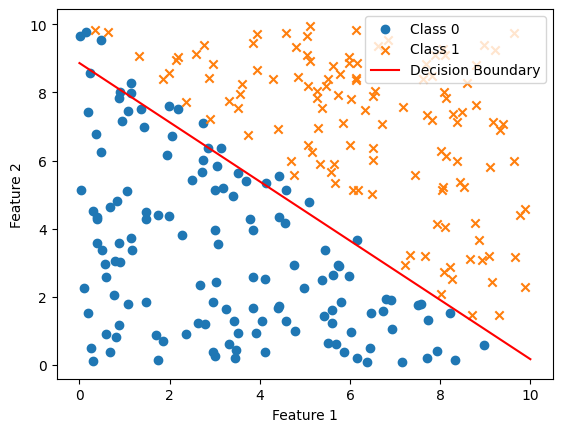

In [105]:
plt.figure()
plt.scatter(X2[y2 == 0, 0], X2[y2 == 0, 1], label="Class 0", marker='o')
plt.scatter(X2[y2 == 1, 0], X2[y2 == 1, 1], label="Class 1", marker='x')

# Decision boundary
w1 = model.linear.weight[0][0].cpu().detach().numpy()
w2 = model.linear.weight[0][1].cpu().detach().numpy()
b = model.linear.bias[0].cpu().detach().numpy()

x_boundary = np.linspace(0, 10, 100)
y_boundary = -(w1 * x_boundary + b) / (w2+1e-12)
plt.plot(x_boundary, y_boundary, color='red', label='Decision Boundary')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()

# Multiclass classification: the MNIST dataset

## Loading the dataset

- MNIST website: http://yann.lecun.com/exdb/mnist/

In [106]:
#rom google.colab import drive
#drive.mount('/content/drive')

In [107]:
from torchvision import datasets, transforms

#dir = '/content/drive/My Drive/BBVA_cursos/MATERIAL_CURSOS/GEN_AI/datasets/MNIST'

# We use datasets function to load MNIST and this will create a Dataset object
train_dataset = datasets.MNIST(root='./', train=True, download=True, transform=transforms.ToTensor())
test_dataset = datasets.MNIST(root='./', train=False, download=True, transform=transforms.ToTensor())

print(len(train_dataset))
print(len(test_dataset))

100%|██████████| 9.91M/9.91M [00:00<00:00, 17.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 483kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]

60000
10000


In [108]:
### Create a validation set
from torch.utils.data.dataset import random_split

torch.manual_seed(1)
train_dataset, val_dataset = random_split(train_dataset, lengths=[55000, 5000])

In [109]:
from torch.utils.data import DataLoader

# Create data loaders: we have a data loader for each dataset
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    shuffle=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=64,
    shuffle=False,
)

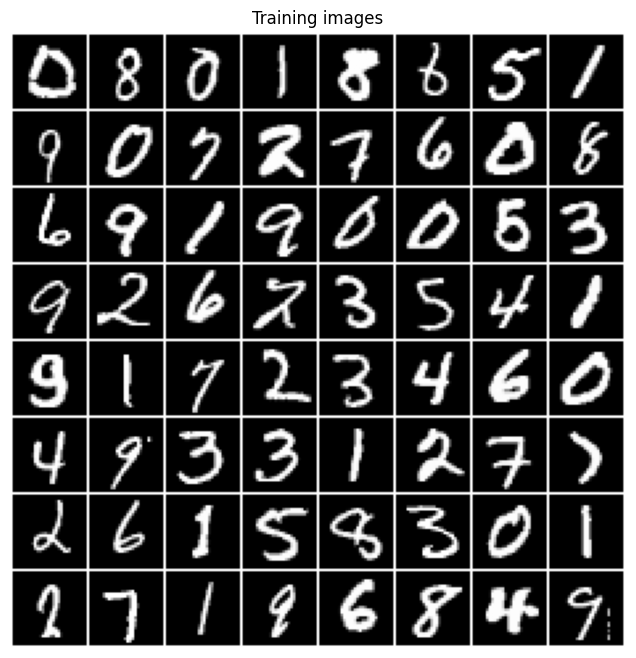

In [110]:
import torchvision

# Let's visualize the data

# We load a batch of data
for images, labels in train_loader:
    break

plt.figure(figsize=(8, 8))
plt.axis("off")
plt.title("Training images")
plt.imshow(np.transpose(torchvision.utils.make_grid(
    images[:64],
    padding=1,
    pad_value=1.0,
    normalize=True),
    (1, 2, 0)))
plt.show()

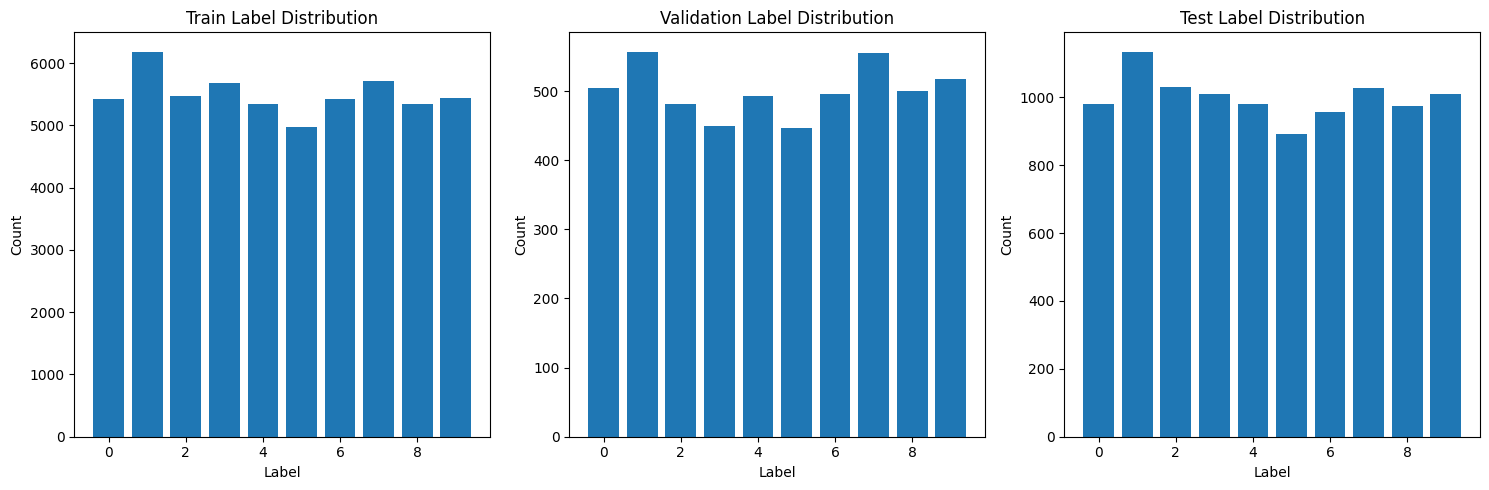

In [111]:
def get_label_counts(dataloader):
    label_counts = {}
    for _, labels in dataloader:
      for label in labels:
        label = label.item()
        if label not in label_counts:
          label_counts[label] = 0
        label_counts[label] += 1
    return label_counts

def plot_label_distribution_per_partition(train_loader, val_loader, test_loader):
  """
  Generates histograms showing the label distribution for each partition.
  """

  train_label_counts = get_label_counts(train_loader)
  val_label_counts = get_label_counts(val_loader)
  test_label_counts = get_label_counts(test_loader)

  plt.figure(figsize=(15, 5))

  plt.subplot(1, 3, 1)
  plt.bar(train_label_counts.keys(), train_label_counts.values())
  plt.title("Train Label Distribution")
  plt.xlabel("Label")
  plt.ylabel("Count")

  plt.subplot(1, 3, 2)
  plt.bar(val_label_counts.keys(), val_label_counts.values())
  plt.title("Validation Label Distribution")
  plt.xlabel("Label")
  plt.ylabel("Count")

  plt.subplot(1, 3, 3)
  plt.bar(test_label_counts.keys(), test_label_counts.values())
  plt.title("Test Label Distribution")
  plt.xlabel("Label")
  plt.ylabel("Count")

  plt.tight_layout()
  plt.show()

# Assuming you have your train_loader, val_loader, and test_loader defined
plot_label_distribution_per_partition(train_loader, val_loader, test_loader)


In [112]:
images.shape # batchsize, channel, height, width

torch.Size([64, 1, 28, 28])

In [113]:
# Let's reshape the data for our LR model
torch.flatten(images, start_dim=1).shape # batchsize, features

torch.Size([64, 784])

**A baseline model (majority class classifier)**

In [114]:
train_label_counts = get_label_counts(train_loader)
majority_class = max(train_label_counts, key=train_label_counts.get)
print("Majority class:", majority_class)

Majority class: 1


In [115]:
test_label_counts = get_label_counts(test_loader)
total_test_data = sum(test_label_counts.values())
majority_class_count_test = test_label_counts.get(majority_class, 0)
ratio_majority_class_test = majority_class_count_test / total_test_data

print(f"Accuracy when always predicting the majority class: {100*ratio_majority_class_test}%")


Accuracy when always predicting the majority class: 11.35%


## Converting the LR to multiclass setting

1. We have to update the model architecture to deal with $M$ outputs -> **softmax regression model**


<img align="center" src="http://www.tsc.uc3m.es/~vanessa/Figs_notebooks/BBVA/GenAI/S1_Fig_6.png" width=80%>



In [116]:
class SoftmaxRegression(torch.nn.Module):

    def __init__(self, num_features, num_categories):
        super().__init__()
        self.linear = torch.nn.Linear(num_features, num_categories)  # We include multiple class labels

    def forward(self, x):
        x = torch.flatten(x, start_dim=1)
        logits = self.linear(x)
        return logits

In [117]:
# We load a batch of data
for images, labels in train_loader:
    break

num_features = images.shape[1] * images.shape[2] * images.shape[3]
num_categories = torch.unique(labels).shape[0]

print(f'Number of features: {num_features}')
print(f'Number of categories: {num_categories}')

model = SoftmaxRegression(num_features= num_features, num_categories=num_categories)
logits = model(images)


Number of features: 784
Number of categories: 10


In [118]:
# Let's consider the output for the first image
logits[:1,:]

tensor([[-0.0521,  0.1274, -0.1152, -0.0680, -0.2643, -0.1232, -0.0540,  0.0856,
         -0.1097, -0.0303]], grad_fn=<SliceBackward0>)

In [119]:
# If we compute the sigmoid
torch.sigmoid(logits[:1,:])

tensor([[0.4870, 0.5318, 0.4712, 0.4830, 0.4343, 0.4692, 0.4865, 0.5214, 0.4726,
         0.4924]], grad_fn=<SigmoidBackward0>)

These probability scores don't sum up to 1!!!! -> Use the sofmax function:

$$\sigma_{softmax} = \frac{e^{z_m}}{\sum_{m=1}^M e^{z_m}}$$

it rescales the probabilities so that they sum up to 1!

In [120]:
import torch.nn.functional as F

softmax_output = F.softmax(logits[:1,:], dim=1)
print(softmax_output)
print(torch.sum(softmax_output).item())

tensor([[0.1003, 0.1200, 0.0942, 0.0987, 0.0811, 0.0934, 0.1001, 0.1151, 0.0947,
         0.1025]], grad_fn=<SoftmaxBackward0>)
1.0000001192092896


To decide which class it belongs to, let's select the index with higher probability:

In [121]:
torch.argmax(softmax_output, dim=1)

tensor([1])

2. We have to update the loss function to deal with multiples classes -> **multicategory cross entropy**


The multicategory cross-entropy es defined as:

$$ L = \sum_{i =1}^N \sum_{m=1}^M  - y_m^{(i)}\log \sigma_{softmax}(z_m^{(i)}) $$

where $z_m^{(i)}$ is the logit associated to the i-th data for the m-th class and $y_m^{(i)}$ its corresponding label with one-hot-encoding codification.

For example,

In [122]:
# Labels for the som data
print(labels[:5])

# OHE codification
y_ohe= F.one_hot(labels, num_classes=num_categories)

# All zeros but 1 in the label position
print(y_ohe[:5])

tensor([1, 4, 0, 8, 6])
tensor([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
        [1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0, 0, 1, 0, 0, 0]])


Then, we can compute the cross entropy as

In [123]:
def multiclass_cross_entropy(logits, labels):
  """
  Computes the multiclass cross-entropy loss.

  Args:
    logits: A tensor of shape (batch_size, num_classes) representing the model's
      logits for each class.
    labels: A tensor of shape (batch_size,) representing the true labels.

  Returns:
    The multiclass cross-entropy loss.
  """

  softmax_output = F.softmax(logits, dim=1)
  one_hot_labels = F.one_hot(labels, num_classes=logits.shape[1])
  loss = -torch.sum(one_hot_labels * torch.log(softmax_output)) / logits.shape[0]
  return loss


CE = multiclass_cross_entropy(logits, labels)
print(CE.item())

2.29899525642395


This is already done by the function cross_entropy! This function computes the softmax over the logits and the ohe encoding of the labels

In [124]:
CE = F.cross_entropy(logits, labels)
print(CE.item())

2.298995018005371


3. Train the softmax regression model

In [125]:
# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Now, we use softmax regression class
model = SoftmaxRegression(num_features= num_features, num_categories=num_categories)
# Send model to device
model.to(device)

# Include the SGD to optimize your model
optimizer = torch.optim.SGD(model.parameters(), lr=0.05)

num_epochs = 100

for epoch in range(num_epochs):
    # Set the model in training mode
    model = model.train()

    # Load the data with minibathes with the data loader
    for batch_idx, (data, labels) in enumerate(train_loader):
        # Send data to device
        data, labels = data.to(device), labels.to(device)

        # Computing the model output with .forward()
        logits = model(data)

        # Now, we use the multiclass cross entropy
        loss = F.cross_entropy(logits, labels)

        # Set the gradients to zero (remove gradients of previous iterations)
        optimizer.zero_grad()

        # Compute the gradients
        loss.backward()

        # Update model parameters
        optimizer.step()

    ### LOGGING
    if epoch%10 ==0:
      print(f'Epoch: {epoch+1:03d}/{num_epochs:03d}'
            f' | Loss: {loss:.2f}')

Using device: cuda
Epoch: 001/100 | Loss: 0.34
Epoch: 011/100 | Loss: 0.57
Epoch: 021/100 | Loss: 0.27
Epoch: 031/100 | Loss: 0.19
Epoch: 041/100 | Loss: 0.19
Epoch: 051/100 | Loss: 0.47
Epoch: 061/100 | Loss: 0.24
Epoch: 071/100 | Loss: 0.13
Epoch: 081/100 | Loss: 0.08
Epoch: 091/100 | Loss: 0.13


In [126]:
def compute_accuracy_multiclass(model, dataloader):
    """Computes the accuracy for a multiclass classification model."""
    model.eval()  # Set the model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in dataloader:
            # Send data to device
            images, labels = images.to(device), labels.to(device)

            logits = model(images)
            predicted_labels = torch.argmax(logits, dim=1)
            correct += (predicted_labels == labels).sum().item()
            total += labels.size(0)

    return correct / total


# Evaluate the multiclass model:
test_acc = compute_accuracy_multiclass(model, test_loader)
print(f"Test Accuracy: {test_acc * 100:.2f}%")


Test Accuracy: 92.61%


Can we improve the performance of this model? It is a linear model... we can make it non-linear, including more layers!!!!